# SHAP + LIME — Two-Level Interpretability
**Level 1 — SHAP on Base Models:** Fitur asli mana yang paling penting  
**Level 2 — SHAP on Meta-Learner:** View/model mana yang paling berpengaruh ke prediksi akhir  
**LIME:** Penjelasan individual per student (local explanation)

---
## 0. Setup & Load Bundles

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import shap
from lime.lime_tabular import LimeTabularExplainer

# ── Load bundles ──────────────────────────────────────────────────────────────
with open('../data/preprocessed_bundle.pkl', 'rb') as f:
    pre = pickle.load(f)

with open('../data/modeling_bundle.pkl', 'rb') as f:
    mod = pickle.load(f)

views_train   = pre['views_train']
views_test    = pre['views_test']
y_train       = pre['y_train']
y_test        = pre['y_test']
feature_names = pre['feature_names']

all_models    = mod['all_models']
meta_learner  = mod['meta_learner']
meta_train    = mod['meta_train']
meta_test     = mod['meta_test']
meta_columns  = mod['meta_columns']
prob_mean     = mod['prob_mean']
y_pred_boot   = mod['y_pred_final']
class_names   = mod['class_names']
view_order    = mod['view_order']
model_names   = mod['model_names']
tiers         = mod['tiers']

PALETTE = {'Graduate': '#2ecc71', 'Enrolled': '#3498db', 'Dropout': '#e74c3c'}

print("Bundles loaded.")
print(f"Views: {list(views_train.keys())}")
print(f"Meta-features: {meta_train.shape[1]}")

Bundles loaded.
Views: ['academic', 'financial', 'demographic', 'macro']
Meta-features: 48


---
## 1. SHAP Level 1 — Feature Importance in Base Models (per View)
Kita analisis **XGBoost** per view karena TreeExplainer yang paling akurat dan cepat untuk tree-based models.

In [2]:
# Compute SHAP values for XGB in each view
shap_values_per_view = {}

for view_name in view_order:
    xgb_model   = all_models[view_name]['XGB']
    X_test_view = views_test[view_name]

    explainer   = shap.TreeExplainer(xgb_model)
    shap_vals   = explainer.shap_values(X_test_view)  # list of arrays (one per class)

    shap_values_per_view[view_name] = {
        'explainer'  : explainer,
        'shap_vals'  : shap_vals,   # shape: [3 classes] × (n_test, n_features)
        'X_test'     : X_test_view,
        'feat_names' : feature_names[view_name]
    }
    print(f"  View [{view_name}]: SHAP computed — {len(feature_names[view_name])} features × {X_test_view.shape[0]} samples")

  View [academic]: SHAP computed — 30 features × 885 samples
  View [financial]: SHAP computed — 4 features × 885 samples
  View [demographic]: SHAP computed — 19 features × 885 samples
  View [macro]: SHAP computed — 3 features × 885 samples


### 1.1 SHAP Summary Plot — Dropout Class, per View

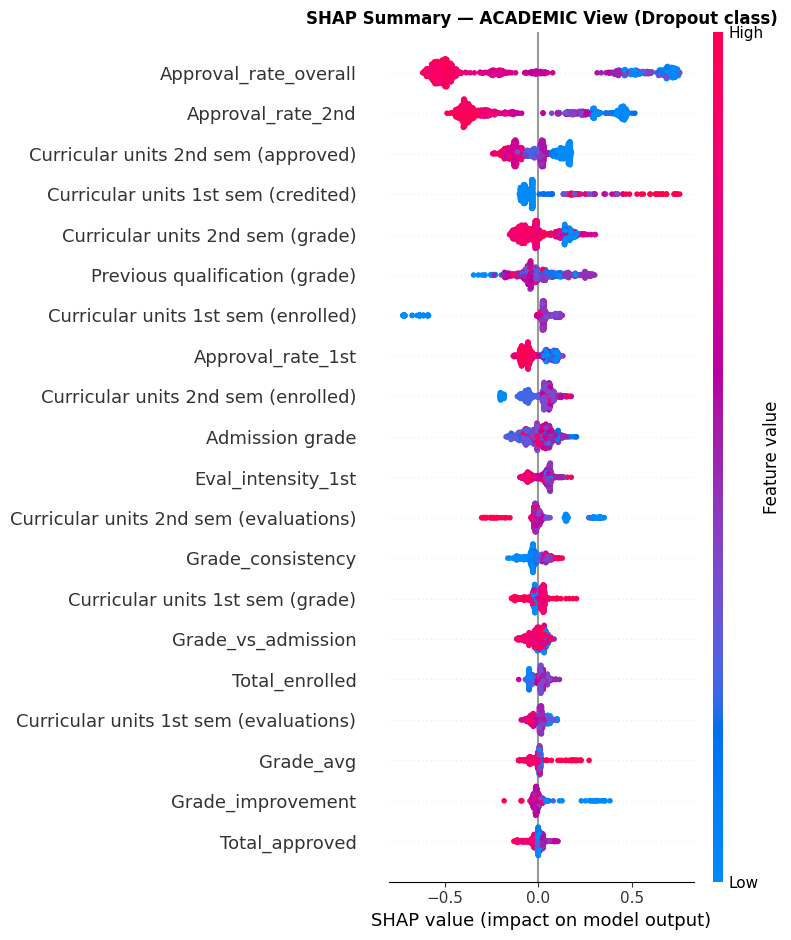

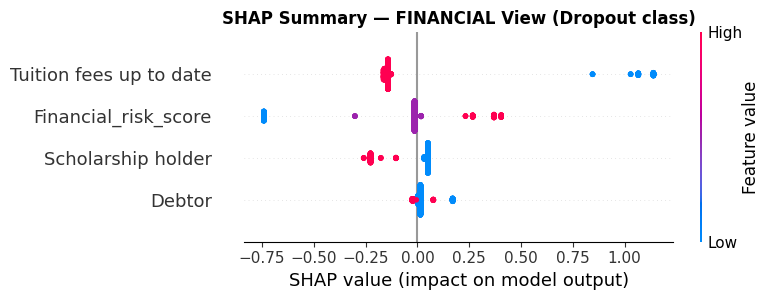

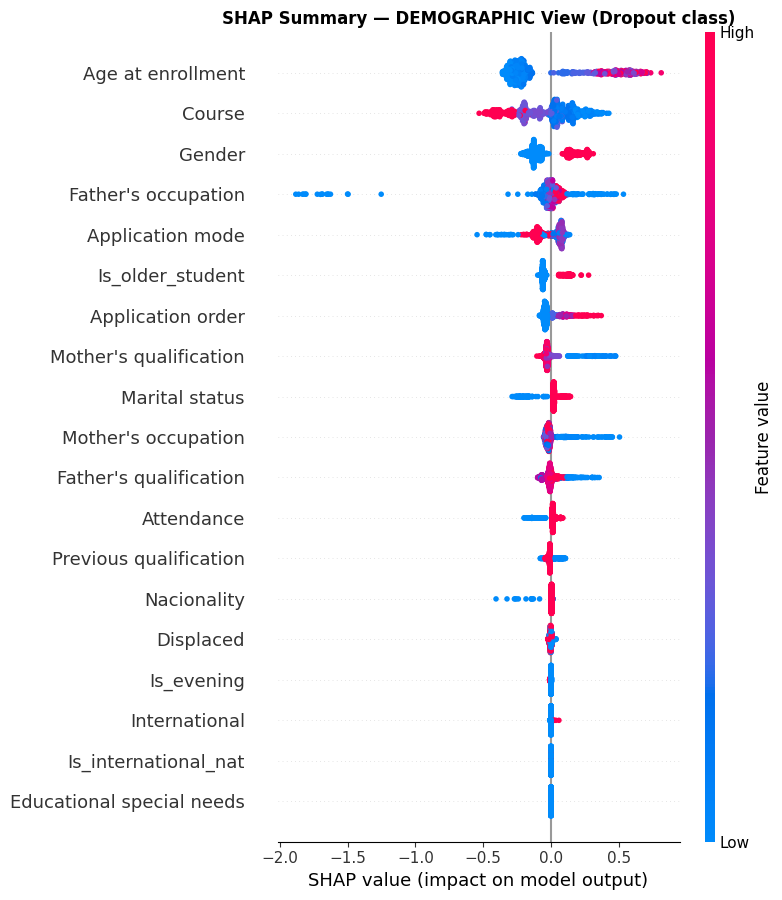

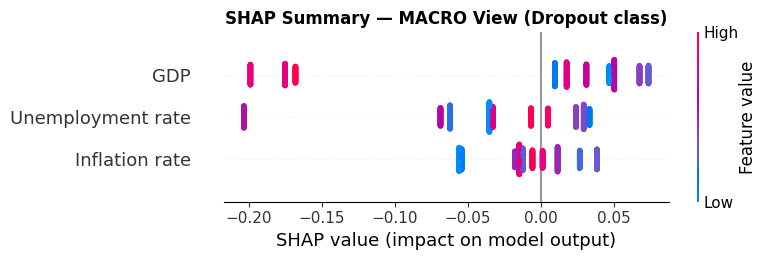

In [3]:
DROPOUT_CLASS_IDX = 2   # class 2 = Dropout

for view_name in view_order:
    data     = shap_values_per_view[view_name]
    sv       = data['shap_vals']
    X_te     = data['X_test']
    fnames   = data['feat_names']

    # Handle both list and 3D array output formats from TreeExplainer
    if isinstance(sv, list):
        sv_dropout = sv[DROPOUT_CLASS_IDX]    # (n_test, n_feat)
    else:
        sv_dropout = sv[:, :, DROPOUT_CLASS_IDX]

    plt.figure(figsize=(10, max(5, len(fnames) * 0.35)))
    shap.summary_plot(
        sv_dropout, X_te,
        feature_names=fnames,
        show=False, plot_type='dot',
        max_display=20
    )
    plt.title(f'SHAP Summary — {view_name.upper()} View (Dropout class)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 1.2 Top Features Comparison — Dropout Class Across All Views

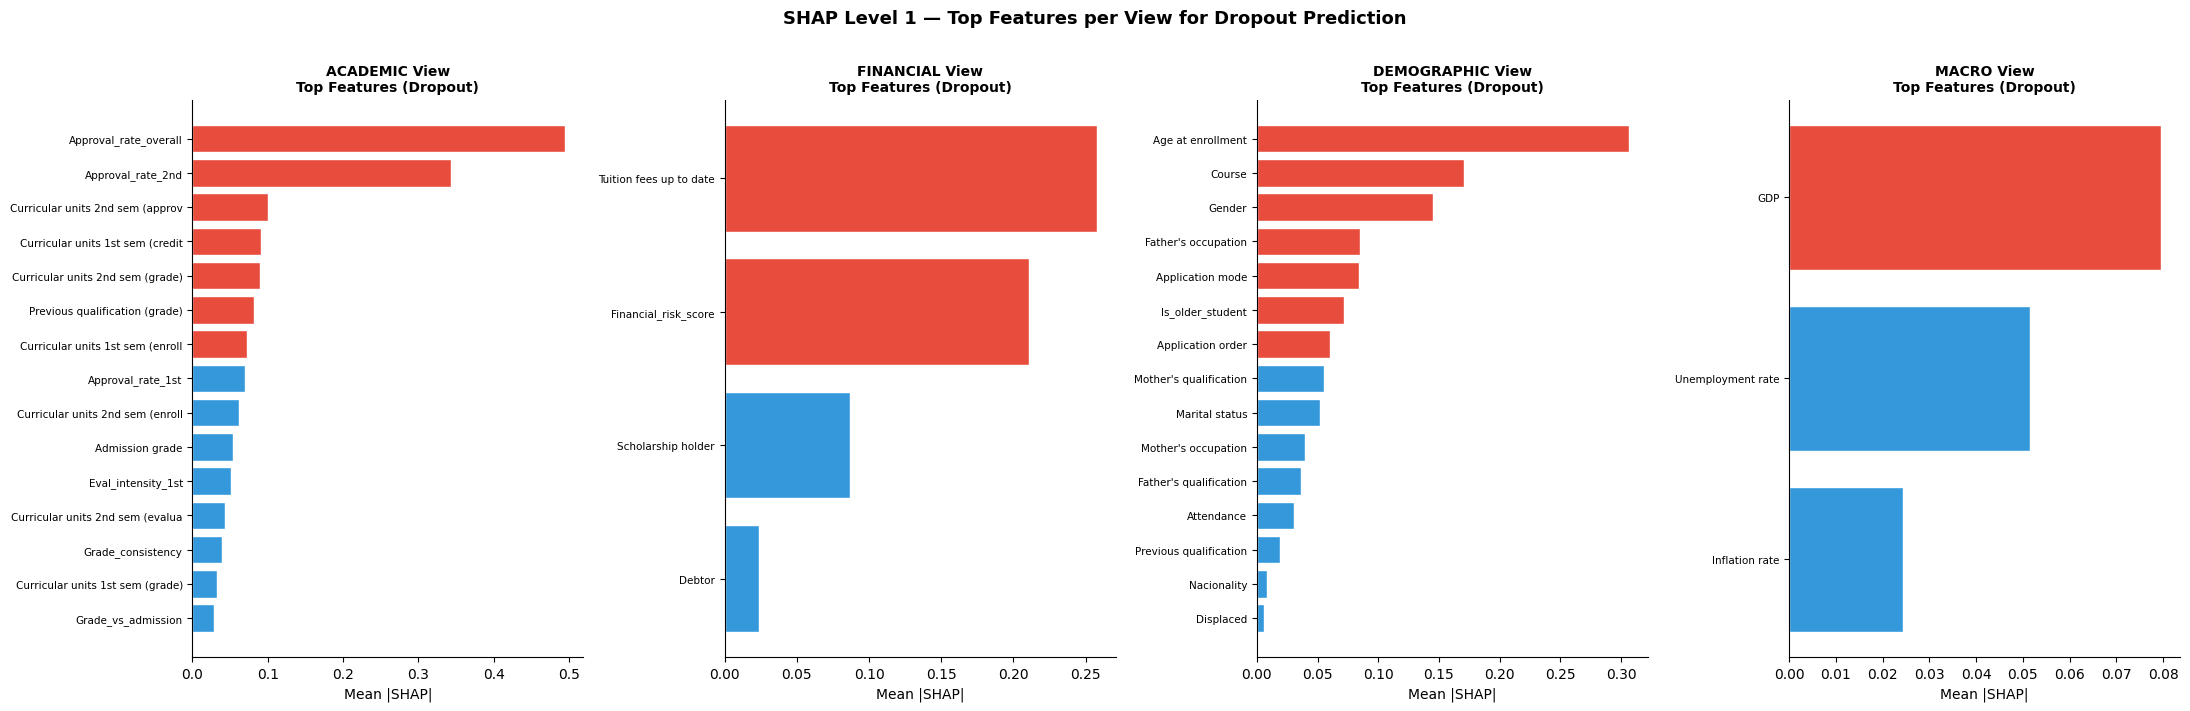

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(22, 7))

for ax, view_name in zip(axes, view_order):
    data     = shap_values_per_view[view_name]
    sv       = data['shap_vals']
    fnames   = data['feat_names']

    if isinstance(sv, list):
        sv_dropout = sv[DROPOUT_CLASS_IDX]
    else:
        sv_dropout = sv[:, :, DROPOUT_CLASS_IDX]

    # Mean |SHAP| per feature
    mean_abs_shap = np.abs(sv_dropout).mean(axis=0)
    feat_imp = pd.Series(mean_abs_shap, index=fnames).sort_values(ascending=True).tail(15)

    colors = ['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values]
    ax.barh(range(len(feat_imp)), feat_imp.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(feat_imp)))
    ax.set_yticklabels([f[:32] for f in feat_imp.index], fontsize=7.5)
    ax.set_title(f'{view_name.upper()} View\nTop Features (Dropout)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('SHAP Level 1 — Top Features per View for Dropout Prediction',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Global Feature Ranking — All Views Combined

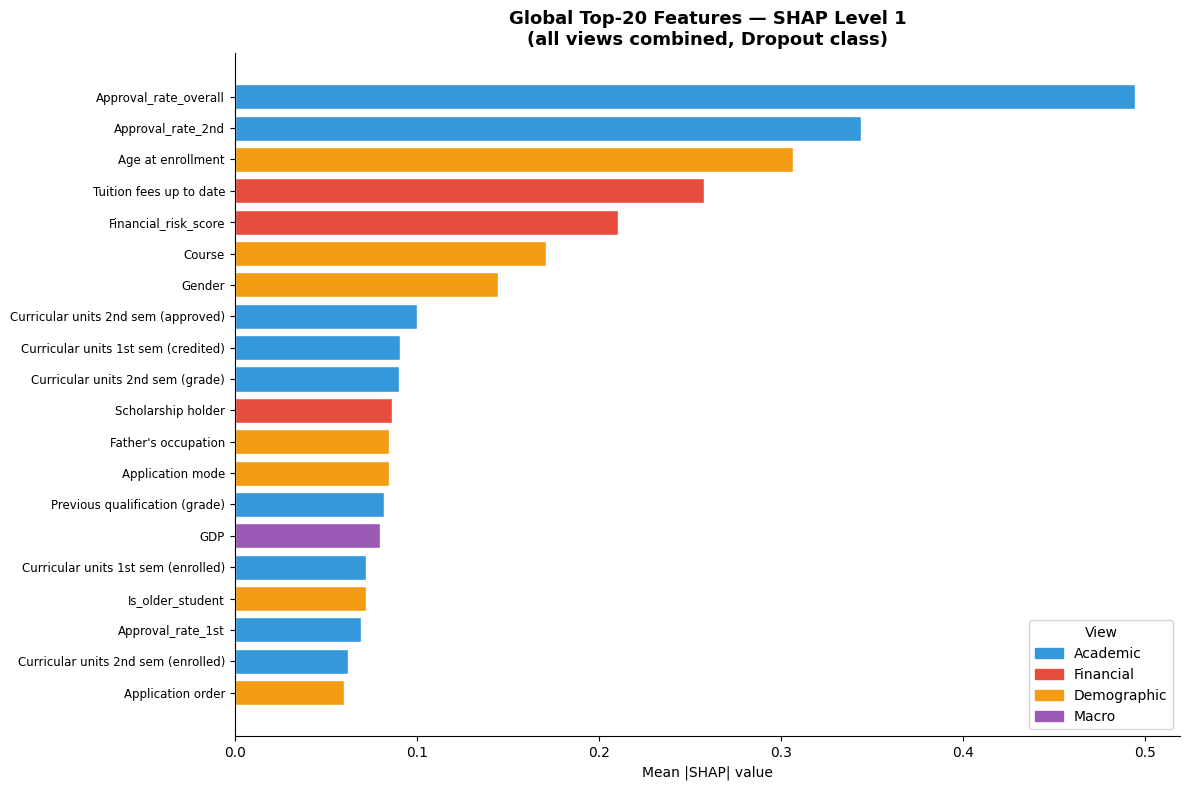


Top 10 most important features globally (Dropout prediction):
                            Feature        View  Mean_SHAP
              Approval_rate_overall    academic   0.494507
                  Approval_rate_2nd    academic   0.343725
                  Age at enrollment demographic   0.306766
            Tuition fees up to date   financial   0.257797
               Financial_risk_score   financial   0.210457
                             Course demographic   0.170905
                             Gender demographic   0.144780
Curricular units 2nd sem (approved)    academic   0.100293
Curricular units 1st sem (credited)    academic   0.090790
   Curricular units 2nd sem (grade)    academic   0.089965


In [5]:
all_feat_importance = []

for view_name in view_order:
    data     = shap_values_per_view[view_name]
    sv       = data['shap_vals']
    fnames   = data['feat_names']

    if isinstance(sv, list):
        sv_dropout = sv[DROPOUT_CLASS_IDX]
    else:
        sv_dropout = sv[:, :, DROPOUT_CLASS_IDX]

    for feat, shap_val in zip(fnames, np.abs(sv_dropout).mean(axis=0)):
        all_feat_importance.append({
            'Feature'  : feat,
            'View'     : view_name,
            'Mean_SHAP': shap_val
        })

fi_df = pd.DataFrame(all_feat_importance).sort_values('Mean_SHAP', ascending=False)
top20 = fi_df.head(20)

view_colors = {'academic': '#3498db', 'financial': '#e74c3c',
               'demographic': '#f39c12', 'macro': '#9b59b6'}

fig, ax = plt.subplots(figsize=(12, 8))
colors = [view_colors[v] for v in top20['View']]
ax.barh(range(len(top20)), top20['Mean_SHAP'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:45] for f in top20['Feature']], fontsize=8.5)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('Global Top-20 Features — SHAP Level 1\n(all views combined, Dropout class)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=v.capitalize()) for v, c in view_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', title='View')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features globally (Dropout prediction):")
print(fi_df.head(10)[['Feature', 'View', 'Mean_SHAP']].to_string(index=False))

---
## 2. SHAP Level 2 — Meta-Learner: Which View/Model Matters Most?
Di sini kita lihat dari 48 meta-features (probabilities dari 16 model base), mana yang paling didengar oleh meta-learner.

In [6]:
# SHAP LinearExplainer for Logistic Regression meta-learner
meta_explainer = shap.LinearExplainer(
    meta_learner,
    meta_train,
    feature_names=meta_columns
)
meta_shap_vals = meta_explainer.shap_values(meta_test)
# meta_shap_vals: list of 3 arrays, each (n_test, 48)

print(f"Meta SHAP computed.")
if isinstance(meta_shap_vals, list):
    print(f"Shape per class: {meta_shap_vals[0].shape}")
else:
    print(f"Shape: {meta_shap_vals.shape}")

InvalidModelError: An unknown model type was passed: <class 'xgboost.sklearn.XGBClassifier'>

In [ ]:
# ── Aggregate SHAP by View and Model ─────────────────────────────────────────
if isinstance(meta_shap_vals, list):
    sv_meta_dropout = meta_shap_vals[DROPOUT_CLASS_IDX]  # (n_test, 48)
else:
    sv_meta_dropout = meta_shap_vals[:, :, DROPOUT_CLASS_IDX]

meta_fi = pd.DataFrame({
    'Column'   : meta_columns,
    'Mean_SHAP': np.abs(sv_meta_dropout).mean(axis=0)
})
meta_fi['View']       = meta_fi['Column'].apply(lambda x: x.split('_')[0])
meta_fi['Model']      = meta_fi['Column'].apply(lambda x: x.split('_')[1])
meta_fi['Pred_class'] = meta_fi['Column'].apply(lambda x: x.split('_')[2])

# Aggregate by View
view_importance = meta_fi.groupby('View')['Mean_SHAP'].sum().sort_values(ascending=False)
# Aggregate by Model
model_importance = meta_fi.groupby('Model')['Mean_SHAP'].sum().sort_values(ascending=False)
# Heatmap: View × Model
heatmap_data = meta_fi.groupby(['View', 'Model'])['Mean_SHAP'].sum().unstack()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# View importance
colors_v = [view_colors[v] for v in view_importance.index]
axes[0].bar(view_importance.index, view_importance.values, color=colors_v, edgecolor='white')
axes[0].set_title('Meta-SHAP: Total Contribution by VIEW\n(Dropout class)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sum |SHAP|')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(view_importance.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Model importance
colors_m = {'SVM': '#3498db', 'XGB': '#e74c3c', 'RF': '#2ecc71', 'KNN': '#f39c12'}
axes[1].bar(model_importance.index, model_importance.values,
            color=[colors_m[m] for m in model_importance.index], edgecolor='white')
axes[1].set_title('Meta-SHAP: Total Contribution by MODEL\n(Dropout class)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Sum |SHAP|')
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(model_importance.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Heatmap View × Model
sns.heatmap(heatmap_data, ax=axes[2], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5)
axes[2].set_title('Meta-SHAP: View × Model\nContribution Heatmap (Dropout)', fontsize=11, fontweight='bold')

plt.suptitle('SHAP Level 2 — Meta-Learner: Which Base Model/View Does It Trust Most?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nMost trusted VIEW by meta-learner (Dropout):")
print(view_importance.to_string())
print("\nMost trusted MODEL by meta-learner (Dropout):")
print(model_importance.to_string())

### 2.1 SHAP Summary Plot — Meta-Learner (Top 20 meta-features)

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_meta_dropout,
    meta_test,
    feature_names=meta_columns,
    show=False,
    max_display=20,
    plot_type='dot'
)
plt.title('SHAP Level 2 — Meta-Learner Feature Importance\n(Dropout class, top 20 meta-features)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. LIME — Individual Student Explanation
LIME memberikan penjelasan **per-student**: kenapa student tertentu diprediksi dropout.

In [ ]:
# ── Wrapper: meta-learner prediction from raw view inputs ────────────────────
# LIME bekerja di satu view — kita pakai Academic view (paling powerful)
# dan wrap XGB model dari Academic view

LIME_VIEW = 'academic'
lime_model  = all_models[LIME_VIEW]['XGB']
lime_X_train= views_train[LIME_VIEW]
lime_X_test = views_test[LIME_VIEW]
lime_fnames = feature_names[LIME_VIEW]

lime_explainer = LimeTabularExplainer(
    lime_X_train,
    feature_names      = lime_fnames,
    class_names        = class_names,
    mode               = 'classification',
    discretize_continuous = True,
    random_state       = 42
)

print(f"LIME explainer built on {LIME_VIEW} view.")
print(f"Features: {len(lime_fnames)}, Classes: {class_names}")

### 3.1 LIME — High-Confidence Dropout Student

In [ ]:
# Find a high-confidence correctly predicted Dropout student
dropout_correct = np.where(
    (y_pred_boot == 2) & (y_test == 2) & (prob_mean[:, 2] > 0.80)
)[0]

if len(dropout_correct) > 0:
    student_idx = dropout_correct[0]
    print(f"Student index : {student_idx}")
    print(f"Actual class  : {class_names[y_test[student_idx]]}")
    print(f"Predicted     : {class_names[y_pred_boot[student_idx]]}")
    print(f"Confidence    : {prob_mean[student_idx].max():.3f}")
    print(f"CI (Dropout)  : [{mod['prob_ci_lo'][student_idx, 2]:.3f} – {mod['prob_ci_hi'][student_idx, 2]:.3f}]")

    exp = lime_explainer.explain_instance(
        lime_X_test[student_idx],
        lime_model.predict_proba,
        num_features=15,
        labels=[2]   # Dropout class
    )

    fig = exp.as_pyplot_figure(label=2)
    plt.title(f'LIME — High-Confidence Dropout Student (idx={student_idx})\n'
              f'Predicted Dropout prob: {prob_mean[student_idx, 2]:.3f}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No high-confidence dropout student found in test set. Adjust threshold.")

### 3.2 LIME — Ambiguous Student (Low Confidence)

In [ ]:
# Find a low-confidence student (ambiguous case — needs human review)
low_conf_dropout = np.where(
    (y_test == 2) & (prob_mean[:, 2] < 0.55) & (prob_mean[:, 2] > 0.30)
)[0]

if len(low_conf_dropout) > 0:
    student_idx = low_conf_dropout[0]
    print(f"Student index : {student_idx}")
    print(f"Actual class  : {class_names[y_test[student_idx]]}")
    print(f"Predicted     : {class_names[y_pred_boot[student_idx]]}")
    print(f"Dropout prob  : {prob_mean[student_idx, 2]:.3f} (ambiguous!)")
    print(f"CI (Dropout)  : [{mod['prob_ci_lo'][student_idx, 2]:.3f} – {mod['prob_ci_hi'][student_idx, 2]:.3f}]")

    exp = lime_explainer.explain_instance(
        lime_X_test[student_idx],
        lime_model.predict_proba,
        num_features=15,
        labels=[2]
    )

    fig = exp.as_pyplot_figure(label=2)
    plt.title(f'LIME — Ambiguous Student (idx={student_idx}) — Needs Manual Review\n'
              f'Dropout prob: {prob_mean[student_idx, 2]:.3f} (uncertainty high)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No ambiguous dropout student found. Adjust threshold.")

### 3.3 LIME — Graduate Student (Why Protected?)

In [ ]:
# Find a high-confidence correctly predicted Graduate student
grad_correct = np.where(
    (y_pred_boot == 0) & (y_test == 0) & (prob_mean[:, 0] > 0.85)
)[0]

if len(grad_correct) > 0:
    student_idx = grad_correct[0]
    print(f"Student index : {student_idx}")
    print(f"Actual class  : {class_names[y_test[student_idx]]}")
    print(f"Graduate prob : {prob_mean[student_idx, 0]:.3f}")

    exp = lime_explainer.explain_instance(
        lime_X_test[student_idx],
        lime_model.predict_proba,
        num_features=15,
        labels=[0]   # Graduate class
    )

    fig = exp.as_pyplot_figure(label=0)
    plt.title(f'LIME — High-Confidence Graduate Student (idx={student_idx})\n'
              f'What protective factors kept this student?',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No high-confidence graduate student found. Adjust threshold.")

---
## 4. SHAP Interaction — Academic View Deep Dive

In [ ]:
# SHAP dependence plots for top 2 academic features
acad_data   = shap_values_per_view['academic']
sv_ac       = acad_data['shap_vals']
X_te_ac     = acad_data['X_test']
fn_ac       = acad_data['feat_names']

if isinstance(sv_ac, list):
    sv_dropout_ac = sv_ac[DROPOUT_CLASS_IDX]
else:
    sv_dropout_ac = sv_ac[:, :, DROPOUT_CLASS_IDX]

# Find top 2 features by mean |SHAP|
mean_abs = np.abs(sv_dropout_ac).mean(axis=0)
top2_idx  = np.argsort(mean_abs)[::-1][:2]
top2_feat = [fn_ac[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_name in zip(axes, top2_feat):
    feat_idx  = fn_ac.index(feat_name)
    feat_vals = X_te_ac[:, feat_idx]
    shap_vals_feat = sv_dropout_ac[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_vals_feat, c=feat_vals, cmap='RdYlGn_r',
                    alpha=0.5, s=15)
    plt.colorbar(sc, ax=ax, label='Feature Value')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(feat_name, fontsize=9)
    ax.set_ylabel('SHAP value (impact on Dropout prob)', fontsize=9)
    ax.set_title(f'SHAP Dependence — {feat_name[:40]}\n(higher SHAP → more Dropout)',
                 fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('SHAP Dependence Plots — Top 2 Academic Features vs. Dropout Impact',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Full Interpretability Report — Student Triage Table

In [ ]:
# Build final student-level report with uncertainty
report_df = pd.DataFrame({
    'Actual'           : [class_names[a] for a in y_test],
    'Predicted'        : [class_names[p] for p in y_pred_boot],
    'Correct'          : (y_pred_boot == y_test),
    'P_Graduate'       : prob_mean[:, 0].round(3),
    'P_Enrolled'       : prob_mean[:, 1].round(3),
    'P_Dropout'        : prob_mean[:, 2].round(3),
    'CI_lo_Dropout'    : mod['prob_ci_lo'][:, 2].round(3),
    'CI_hi_Dropout'    : mod['prob_ci_hi'][:, 2].round(3),
    'Uncertainty'      : mod['prob_std'].max(axis=1).round(3),
    'Tier'             : tiers['Tier'].values
})

print("Sample report (top 10 high-risk Dropout predictions):")
high_risk = report_df[
    (report_df['Predicted'] == 'Dropout') &
    (report_df['P_Dropout'] >= 0.6)
].sort_values('P_Dropout', ascending=False).head(10)

display_cols = ['Actual', 'Predicted', 'P_Dropout', 'CI_lo_Dropout', 'CI_hi_Dropout', 'Uncertainty', 'Tier']
print(high_risk[display_cols].to_string(index=True))

print(f"\nTotal high-risk dropout students (P>0.6): {len(high_risk)} out of {(report_df['Predicted']=='Dropout').sum()} predicted dropouts")

In [ ]:
# Save final report
report_df.to_csv('../data/student_prediction_report.csv', index=True)

# Save SHAP values for reuse
shap_bundle = {
    'shap_values_per_view' : shap_values_per_view,
    'meta_shap_vals'       : meta_shap_vals,
    'meta_fi'              : meta_fi,
    'view_importance'      : view_importance,
    'model_importance'     : model_importance,
    'all_feat_importance'  : fi_df,
    'report_df'            : report_df
}
with open('../data/shap_bundle.pkl', 'wb') as f:
    pickle.dump(shap_bundle, f)

print("Saved:")
print("  ../data/student_prediction_report.csv")
print("  ../data/shap_bundle.pkl")

---
## 6. Summary — Interpretability Insights

```
TWO-LEVEL INTERPRETABILITY COMPLETE
══════════════════════════════════════════════════════════════════════

SHAP LEVEL 1 — Base Model (Feature-level)
  → Answers: "Fitur asli mana yang paling mempengaruhi prediksi Dropout?"
  → Method : TreeExplainer pada XGBoost per view
  → Output : Summary plot, dependence plot, global ranking

  Expected top features:
    [Academic]   Approved units, grade, approval rate, zero_eval_flag
    [Financial]  Tuition up to date, debtor, scholarship
    [Demographic]Age, gender, application mode
    [Macro]      Unemployment rate, GDP

SHAP LEVEL 2 — Meta-Learner (Model/View-level)
  → Answers: "View dan model mana yang paling dipercaya meta-learner?"
  → Method : LinearExplainer pada Logistic Regression meta-learner
  → Output : View importance, model importance, heatmap

  Expected: Academic view >> Financial view >> Demographic > Macro
            XGB >> RF >> SVM >> KNN (generally)

LIME — Local Explanation (Student-level)
  → Answers: "Kenapa student TERTENTU ini diprediksi Dropout?"
  → 3 student profiles analyzed:
     1. High-confidence Dropout (what pushed them over?)
     2. Ambiguous case (why uncertain → manual review)
     3. High-confidence Graduate (what protected them?)

TRIAGE SYSTEM:
  High Confidence   → act immediately (very reliable prediction)
  Medium Confidence → monitor closely
  Low Confidence    → human counselor review

Saved files:
  student_prediction_report.csv → full test set predictions + CI
  shap_bundle.pkl               → all SHAP values for further analysis
══════════════════════════════════════════════════════════════════════
```